In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/Air_Quality.csv")
df.head()


,Unique ID,Indicator ID,Name,Measure,Measure Info,Geo Type Name,Geo Join ID,Geo Place Name,Time Period,Start_Date,Data Value,Message
0,742475,365,Fine particles (PM 2.5),Mean,mcg/m3,CD,304,Bushwick (CD4),Summer 2021,06/01/2021,8.778826,NaN
1,877252,375,Nitrogen dioxide (NO2),Mean,ppb,CD,412,Jamaica and Hollis (CD12),Winter 2022-23,12/01/2022,19.657097,NaN
2,743686,386,Ozone (O3),Mean,ppb,UHF42,503,Willowbrook,Summer 2021,06/01/2021,29.086208,NaN
3,825986,375,Nitrogen dioxide (NO2),Mean,ppb,UHF42,502,Stapleton - St. George,Winter 2021-22,12/01/2021,18.562443,NaN
4,643406,375,Nitrogen dioxide (NO2),Mean,ppb,UHF42,402,West Queens,Summer 2019,06/01/2019,15.580000,NaN


Exploratory Data Analysis — Air Quality Dataset

This notebook performs an exploratory analysis of the Air Quality dataset obtained from Data.gov.
The objective is to understand the structure of the dataset, identify potential issues such as missing values or outliers, and explore patterns in air pollution measurements across locations and time periods.

The insights obtained here will guide the preprocessing pipeline and feature engineering steps used later in the machine learning workflow.

In [43]:
df.shape




(18862, 12)

In [44]:
df.columns

Index(['Unique ID', 'Indicator ID', 'Name', 'Measure', 'Measure Info',
       'Geo Type Name', 'Geo Join ID', 'Geo Place Name', 'Time Period',
       'Start_Date', 'Data Value', 'Message'],
      dtype='object')

In [45]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18862 entries, 0 to 18861
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Unique ID       18862 non-null  int64  
 1   Indicator ID    18862 non-null  int64  
 2   Name            18862 non-null  object 
 3   Measure         18862 non-null  object 
 4   Measure Info    18862 non-null  object 
 5   Geo Type Name   18862 non-null  object 
 6   Geo Join ID     18862 non-null  int64  
 7   Geo Place Name  18862 non-null  object 
 8   Time Period     18862 non-null  object 
 9   Start_Date      18862 non-null  object 
 10  Data Value      18862 non-null  float64
 11  Message         0 non-null      float64
dtypes: float64(2), int64(3), object(7)
memory usage: 1.7+ MB


The dataset contains air pollutant measurements across different geographic areas and time periods.
Each record includes the pollutant type, measurement value, location, and date.

In [40]:
df["Name"].value_counts()

Name
Fine particles (PM 2.5)                                   6345
Nitrogen dioxide (NO2)                                    6345
Ozone (O3)                                                2115
Asthma hospitalizations due to Ozone                       480
Asthma emergency departments visits due to Ozone           480
Asthma emergency department visits due to PM2.5            480
Annual vehicle miles traveled (trucks)                     321
Annual vehicle miles traveled                              321
Annual vehicle miles traveled (cars)                       321
Deaths due to PM2.5                                        240
Cardiac and respiratory deaths due to Ozone                240
Cardiovascular hospitalizations due to PM2.5 (age 40+)     240
Respiratory hospitalizations due to PM2.5 (age 20+)        240
Outdoor Air Toxics - Formaldehyde                          203
Outdoor Air Toxics - Benzene                               203
Boiler Emissions- Total SO2 Emissions             

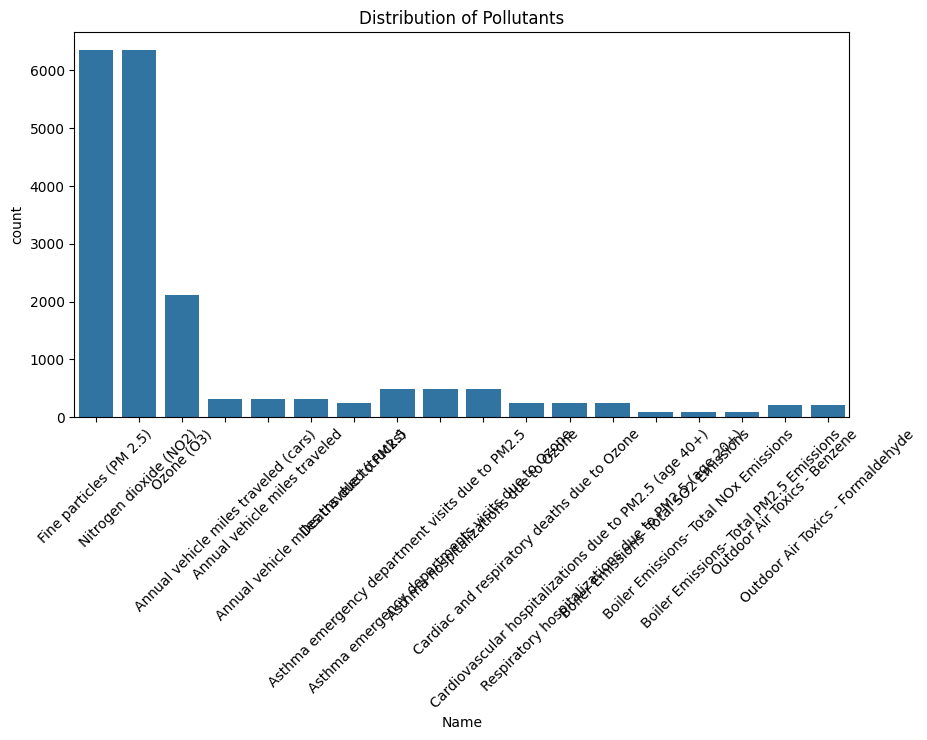

In [46]:
plt.figure(figsize=(10,5))
sns.countplot(data=df, x="Name")
plt.xticks(rotation=45)
plt.title("Distribution of Pollutants")
plt.show()

The dataset includes multiple pollutants such as PM2.5, Nitrogen Dioxide (NO2), and Ozone (O3).
Understanding their distribution is important for evaluating class balance in the classification task.

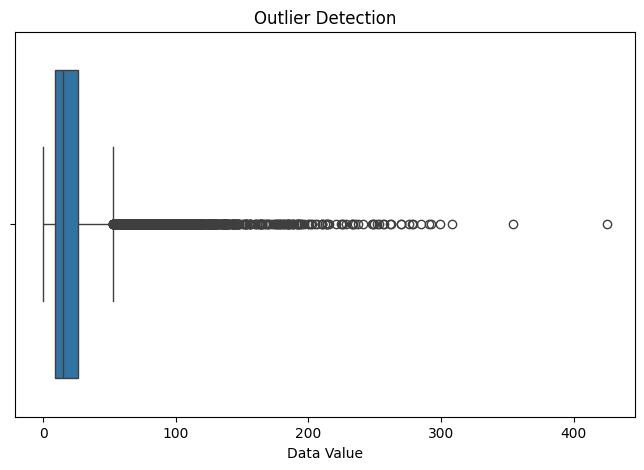

In [47]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df["Data Value"])
plt.title("Outlier Detection")
plt.show()

The boxplot shows the presence of extreme outliers in pollution measurements.
These values will be addressed during preprocessing using the Interquartile Range (IQR) method.

In [48]:
df["Start_Date"] = pd.to_datetime(df["Start_Date"])

In [49]:
df["year"] = df["Start_Date"].dt.year
df["month"] = df["Start_Date"].dt.month
df["day_of_week"] = df["Start_Date"].dt.dayofweek

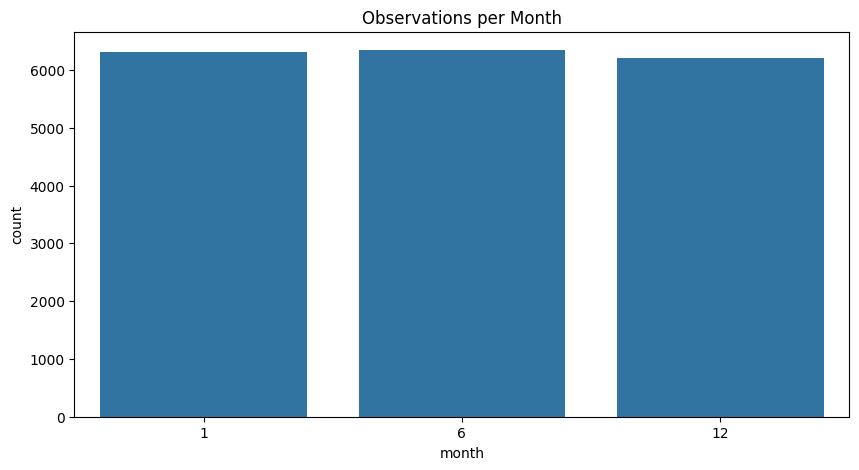

In [50]:
plt.figure(figsize=(10,5))
sns.countplot(x="month", data=df)
plt.title("Observations per Month")
plt.show()

Temporal feature extraction allows the model to capture seasonal variations in pollutant levels.

In [51]:
df["Geo Place Name"].value_counts().head(10)

Geo Place Name
Central Harlem - Morningside Heights    281
Southwest Queens                        281
Jamaica                                 281
Washington Heights                      281
East Harlem                             281
Northeast Bronx                         281
Flushing - Clearview                    281
Greenpoint                              281
Ridgewood - Forest Hills                281
East New York                           281
Name: count, dtype: int64

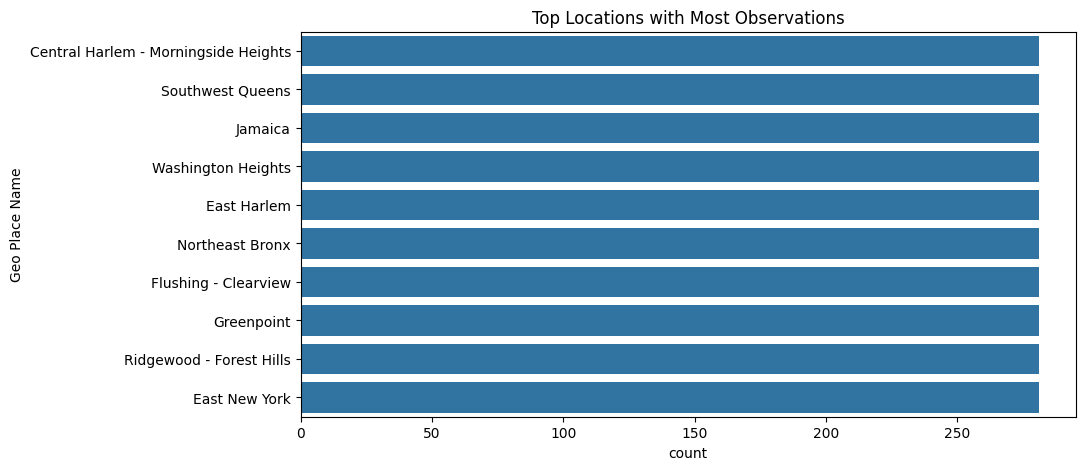

In [52]:
top_places = df["Geo Place Name"].value_counts().head(10).index

plt.figure(figsize=(10,5))
sns.countplot(data=df[df["Geo Place Name"].isin(top_places)],
              y="Geo Place Name",
              order=top_places)

plt.title("Top Locations with Most Observations")
plt.show()

some locations contain significantly more observations than others, which could influence model training.

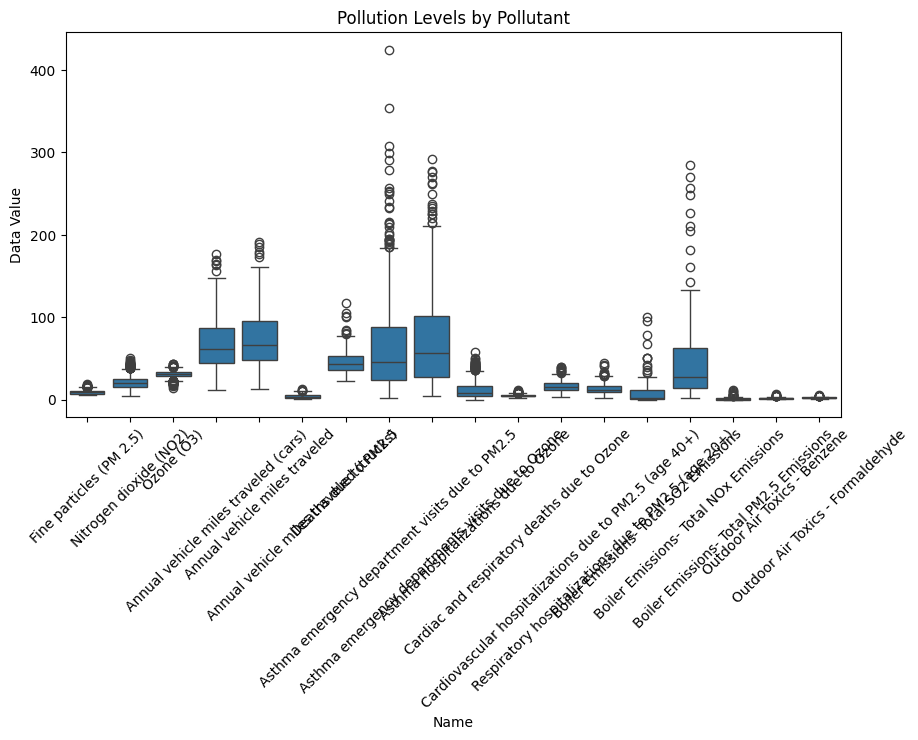

In [53]:
plt.figure(figsize=(10,5))
sns.boxplot(data=df, x="Name", y="Data Value")
plt.xticks(rotation=45)
plt.title("Pollution Levels by Pollutant")
plt.show()

Different pollutants operate at different measurement scales.
This confirms the need for feature scaling during preprocessing.

In [54]:
df.isnull().sum()

Unique ID             0
Indicator ID          0
Name                  0
Measure               0
Measure Info          0
Geo Type Name         0
Geo Join ID           0
Geo Place Name        0
Time Period           0
Start_Date            0
Data Value            0
Message           18862
year                  0
month                 0
day_of_week           0
dtype: int64

The column Message contains only missing values and will be removed during preprocessing.
Other attributes show minimal missing data.

Key Findings

-The dataset contains multiple pollutants measured across locations and time.
-Pollution measurements show a right-skewed distribution with extreme outliers.
-Some geographic areas have significantly more observations than others.
-Pollutants operate on different measurement scales.

Based on these findings, the preprocessing pipeline will include:

-Removal of non-informative columns
-Temporal feature engineering
-Outlier filtering using IQR
-Target encoding
-One-hot encoding of categorical variables
-Feature scaling using StandardScaler